In [22]:
# Import libraries and list files

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm import tqdm

In [24]:
!pip install seaborn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_dataframe(df, columna='value'):
    # 1. Estadísticas descriptivas detalladas
    stats = df[columna].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    print("--- Estadísticas de la columna Value ---")
    print(stats)
    
    # 2. Conteo de ceros exactos
    ceros = (df[columna] == 0).sum()
    pct_ceros = (ceros / len(df)) * 100
    print(f"\nCeros absolutos: {ceros} ({pct_ceros:.2f}%)")
    
    # 3. Visualización dual
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Histograma con KDE (línea de densidad)
    sns.histplot(df[columna], bins=100, kde=True, ax=ax1, color='teal')
    ax1.set_title('Distribución Global (Histograma)')
    
    # Boxplot para ver los "Outliers" (los famosos 152 y -152)
    sns.boxplot(x=df[columna], ax=ax2, color='coral')
    ax2.set_title('Detección de Valores Extremos (Boxplot)')
    
    plt.tight_layout()
    plt.show()

# Uso:
# analizar_dataframe(mi_dataframe)

In [45]:
df0 = pd.read_csv("lc0_normal_fens.csv")
converted = pd.to_numeric(df0['value'], errors="coerce")
df0["value"] = pd.to_numeric(df0["value"], errors="coerce")
df0 = df0.dropna(subset=["value"])
#print(df0.loc[converted.isna() & df0['value'].notna()])

df0

,FEN,move,value
0,fen,d2d4,0.0387
1,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,0.0387
2,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,e7e5,-0.0598
3,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,g1f3,0.0547
4,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,c7c6,-0.0975
...,...,...,...
83842,5k2/5p1p/1p3N2/pP6/3Pp1P1/1b2P1QP/2r5/7K b - -...,c2c1,-0.5596
83843,5k2/5p1p/1p3N2/pP6/3Pp1P1/1b2P1QP/8/2r4K w - -...,h1h2,0.0912
83844,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,0.0387
83845,rnbqkbnr/pppppppp/8/8/8/1P6/P1PPPPPP/RNBQKBNR ...,d7d5,-0.0429


In [46]:
print("--- Análisis del campo Value ---")
print(f"Valor Máximo: {df0['value'].max()}")
print(f"Valor Mínimo: {df0['value'].min()}")
print(f"Valor Promedio: {df0['value'].mean()}")

analizar_dataframe(df0)

In [50]:
df_high = df0[abs(df0["value"]) > 0.99]

print(df_high)
print("Cantidad:", len(df_high))

df0[df0["value"] == 0].head(20)

                                                   FEN  move   value
957            8/1p6/k2p4/3P3p/7K/2P1N3/8/8 w - - 4 56  h4h5  0.9938
958             8/1p6/k2p4/3P3K/8/2P1N3/8/8 b - - 0 56  a6b5 -0.9969
959             8/1p6/3p4/k2P3K/8/2P1N3/8/8 w - - 1 57  h5g6  0.9959
960            8/1p6/3p2K1/k2P4/8/2P1N3/8/8 b - - 2 57  a5b5 -0.9974
961            8/1p6/3p2K1/3P4/k7/2P1N3/8/8 w - - 3 58  g6f6  0.9950
...                                                ...   ...     ...
83437  1K2QB2/7k/3qp3/p3Pp1p/3P1PpP/6P1/8/8 w - - 8 97  e5d6  0.9979
83438   1K2QB2/7k/3Pp3/p4p1p/3P1PpP/6P1/8/8 b - - 0 97  h7g8 -0.9999
83439   1K2QB2/7k/3Pp3/5p1p/p2P1PpP/6P1/8/8 w - - 0 98  e8f7  0.9999
83440  1K3B2/5Q1k/3Pp3/5p1p/p2P1PpP/6P1/8/8 b - - 1 98  h7h8 -0.9999
83441  1K3B1k/5Q2/3Pp3/5p1p/p2P1PpP/6P1/8/8 w - - 2 99  f7g7  1.0000

[3035 rows x 3 columns]
Cantidad: 3035


,FEN,move,value
650,2Q5/6k1/5p2/3qpp1p/7P/6P1/5P2/6K1 w - - 2 39,c8f5,0.0
5146,5k2/7P/8/p2K4/P7/8/8/bB6 b - - 16 144,f8g7,-0.0
5147,5k2/7P/8/p2K4/P7/8/1b6/1B6 w - - 17 145,b1a2,0.0
5149,5k2/7P/4K3/p7/P7/8/8/bB6 w - - 19 146,e6d5,0.0
5150,5k2/7P/4K3/p4B2/P7/8/8/b7 b - - 20 146,f8g7,-0.0
5154,5k2/7P/4K3/p7/P7/8/2B5/b7 b - - 24 148,f8g7,-0.0
5155,5k2/7P/4K3/p7/P7/8/1bB5/8 w - - 25 149,c2d3,0.0
5157,5k2/7P/3K4/p7/P7/8/2B5/b7 w - - 27 150,h7h8b,-0.0
5158,5k2/7P/4K3/p7/P7/8/2B5/b7 b - - 28 150,f8g7,-0.0
5159,5k2/7P/4K3/p7/P7/2b5/2B5/8 w - - 29 151,c2g6,0.0


--- Estadísticas de la columna Value ---
count    1.460135e+06
mean     3.769860e-02
std      4.127295e-01
min     -1.000000e+00
1%      -1.000000e+00
5%      -8.564849e-01
25%     -1.046158e-01
50%      0.000000e+00
75%      2.117473e-01
95%      9.086977e-01
99%      1.000000e+00
max      1.000000e+00
Name: value, dtype: float64

Ceros absolutos: 233025 (15.96%)


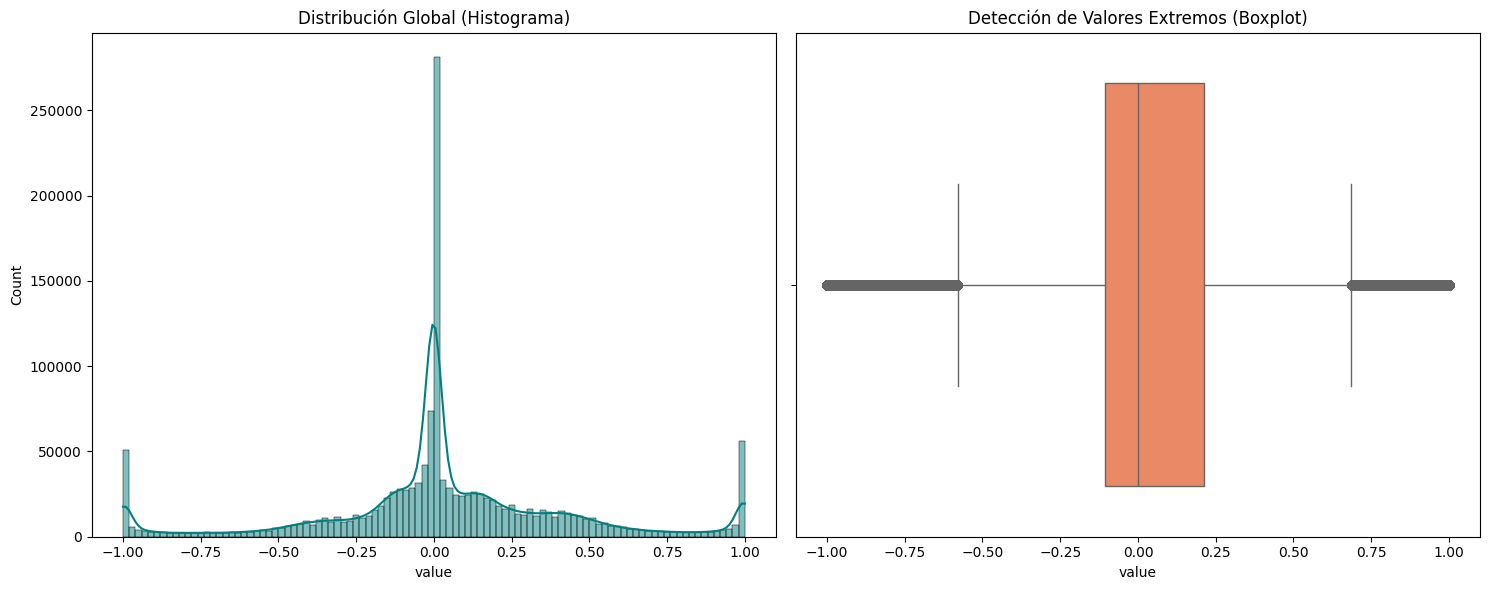

In [9]:
#df0['value'] = (df0['value'] / 152.65).clip(-1, 1)
#df0['value'] = np.tanh(df0['value'] / 2.0)
analizar_dataframe(df0)

In [65]:
def get_fullmove(fen):
    try:
        return int(fen.split()[-1])
    except (ValueError, AttributeError, IndexError):
        return None  # o np.nan

df0["fullmove"] = df0["FEN"].apply(get_fullmove)
df0 = df0[df0["fullmove"].notna()]
df_filtered = df0[
    ~((df0["fullmove"] > 100) & (df0["value"].abs() < 0.05))
]

replacement_moves = ['e2e4', 'c2c4', 'g1f3']
mask = (df_filtered['fullmove'] == 1) & (df_filtered['move'] == 'd2d4')
idx_to_replace = df_filtered[mask].index

# Tomamos un 50% al azar de estas filas
n_replace = int(len(idx_to_replace) * 0.5)
replace_indices = np.random.choice(idx_to_replace, size=n_replace, replace=False)

# Elegimos movimientos de reemplazo al azar
df_filtered.loc[replace_indices, 'move'] = np.random.choice(replacement_moves, size=n_replace, replace=True)


df_filtered

,FEN,move,value,fullmove
1,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,0.0387,1
2,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,e7e5,-0.0598,1
3,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,g1f3,0.0547,2
4,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,c7c6,-0.0975,2
5,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,b1c3,0.1782,3
...,...,...,...,...
83842,5k2/5p1p/1p3N2/pP6/3Pp1P1/1b2P1QP/2r5/7K b - -...,c2c1,-0.5596,45
83843,5k2/5p1p/1p3N2/pP6/3Pp1P1/1b2P1QP/8/2r4K w - -...,h1h2,0.0912,46
83844,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,g1f3,0.0387,1
83845,rnbqkbnr/pppppppp/8/8/8/1P6/P1PPPPPP/RNBQKBNR ...,d7d5,-0.0429,1


In [66]:
df_starts = df_filtered[(df_filtered["fullmove"] == 1)]
df_starts['move'].value_counts()

move
d2d4    282
e7e5    231
d7d5    207
g1f3    101
g8f6     93
e2e4     92
c2c4     88
g7g6     18
b7b6     14
Name: count, dtype: int64

In [10]:
print("--- Análisis del campo Value NORMALIZADO ---")
print(f"Valor Máximo: {df0['value'].max()}")
print(f"Valor Mínimo: {df0['value'].min()}")
print(f"Valor Promedio: {df0['value'].mean()}")
df0

--- Análisis del campo Value NORMALIZADO ---
Valor Máximo: 1.0
Valor Mínimo: -1.0
Valor Promedio: 0.037698598916241666


,fen,move,value
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,c2c4,0.000000
1,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,g8f6,0.000000
2,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,d2d4,0.000000
3,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,d7d6,0.000000
4,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,g1f3,0.000000
...,...,...,...
1460130,8/P1R5/6k1/4p3/8/5Kp1/r7/8 b - - 1 53,g3g2,0.029991
1460131,8/P1R5/6k1/4p3/8/5K2/r5p1/8 w - - 0 54,c7c1,-0.010000
1460132,8/P7/6k1/4p3/8/5K2/r5p1/2R5 b - - 1 54,g6f5,0.034986
1460133,8/P7/8/4pk2/8/5K2/r5p1/2R5 w - - 2 55,a7a8q,0.000000


In [23]:
df1 = pd.read_csv("dataset_train1.csv")
df2 = pd.read_csv("dataset_train2.csv")
df3 = pd.read_csv("dataset_train3.csv")
df4 = pd.read_csv("dataset_train4.csv")

df = pd.concat([df0,df1,df2,df3,df4],ignore_index=True)
print("--- Análisis del campo Value ---")
print(f"Valor Máximo: {df['value'].max()}")
print(f"Valor Mínimo: {df['value'].min()}")
print(f"Valor Promedio: {df['value'].mean()}")



--- Análisis del campo Value ---
Valor Máximo: 9997.95
Valor Mínimo: -9997.94
Valor Promedio: 0.6332931026454985


--- Análisis del campo Value NORMALIZADO ---
Valor Máximo: 1.0
Valor Mínimo: -1.0
Valor Promedio: 0.036974704231109164
--- Estadísticas de la columna Value ---
count    3.135666e+06
mean     3.697470e-02
std      4.068569e-01
min     -1.000000e+00
1%      -1.000000e+00
5%      -8.381731e-01
25%     -9.966799e-02
50%      0.000000e+00
75%      2.021758e-01
95%      9.005270e-01
99%      1.000000e+00
max      1.000000e+00
Name: value, dtype: float64

Ceros absolutos: 525604 (16.76%)


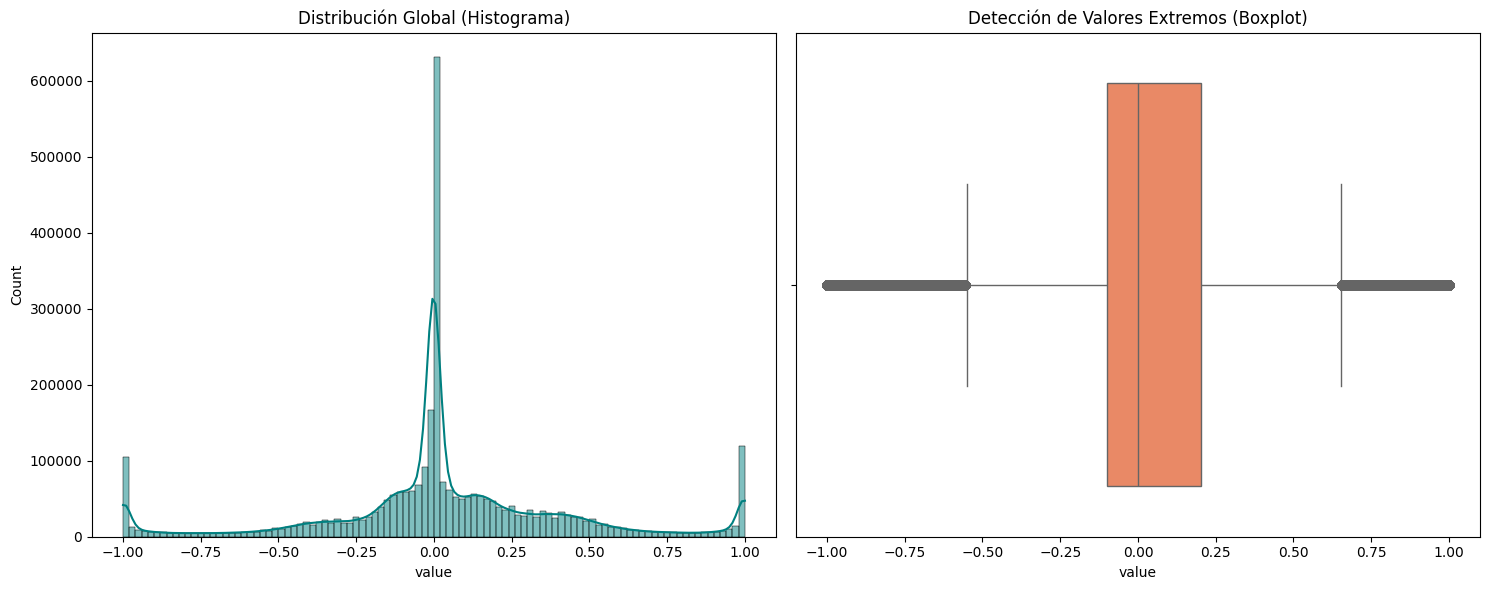

In [24]:
df['value'] = np.tanh(df['value'] / 2.0) 

print("--- Análisis del campo Value NORMALIZADO ---")
print(f"Valor Máximo: {df['value'].max()}")
print(f"Valor Mínimo: {df['value'].min()}")
print(f"Valor Promedio: {df['value'].mean()}")
analizar_dataframe(df)

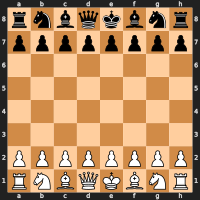

In [18]:
import chess
import chess.svg
from IPython.display import display, SVG

# Define un FEN de ejemplo (posición inicial)
fen_example = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"

# Crea un objeto de tablero de ajedrez
board = chess.Board(fen=fen_example)

# Muestra el tablero en formato SVG (gráficamente en el notebook)
svg_board = chess.svg.board(board=board, size=200)
display(SVG(svg_board))

In [25]:

# Convert board in matrix of the pieces of some type. 
def board_to_matrix(board, piece_type):
    piece_map = board.piece_map()
    matrix = np.zeros((8,8))

    for square, piece in piece_map.items():
        # chess.square_rank y chess.square_file return row and column
        rank = chess.square_rank(square)
        file = chess.square_file(square)
        if(piece.piece_type == piece_type):
            matrix[7 - rank, file] = (-1 if piece.color == chess.BLACK else 1) * 1 # piece.piece_type 
    return matrix

# Convert board in 13x8x8 with every type/color piece in a layer and a layer for turn.
def board2rep(board):
    pieces = [1,2,3,4,5,6]
    layers = []
    for piece in pieces:
        matrix = board_to_matrix(board,piece)
        white_matrix = np.where(matrix == 1, 1, 0)
        black_matrix = np.where(matrix == -1, 1, 0)
        
        layers.append(white_matrix)
        layers.append(black_matrix)
    if board.turn:
        color_matrix = np.ones((8,8))
        layers.append(color_matrix)
    else:
        color_matrix = np.zeros((8,8))
        layers.append(color_matrix)
        
    board_rep = np.stack(layers)
    board_rep = board_rep.astype(bool)
    return board_rep


    # Definition of the moves as a dictionary of tuples 
codes, i = {}, 0
    # All 56 regular moves of a Queen or other normal pieces
for nSquares in range(1,8):
    for direction in [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]:
        codes[(nSquares*direction[0],nSquares*direction[1])] = i
        i += 1
    # 8 Knight moves
codes[(1,2)], i = i,  i+1
codes[(2,1)], i = i,  i+1
codes[(2,-1)], i = i,  i+1
codes[(1,-2)], i = i,  i+1
codes[(-1,-2)], i = i,  i+1
codes[(-2,-1)], i = i,  i+1
codes[(-2,1)], i = i,  i+1
codes[(-1,2)], i = i,  i+1 

    # We avoid pawn promotion because are the same moves and we are looking for 1 best move. 

# Extract and convert legal moves to the 64x8x8 matrix. 
def legal_moves_to_64_8_8(board):

    legal_moves = list(board.legal_moves)
    
    # Apply the function to each move in the list
    extracted_moves = [[
        [chess.square_rank(m.from_square),chess.square_file(m.from_square)], 
         (chess.square_file(m.to_square) - chess.square_file(m.from_square), chess.square_rank(m.to_square) - chess.square_rank(m.from_square))
    ] for m in legal_moves]

    # Creation of the array and apply the moves:
    array6488 = np.zeros((64,8,8))
    for em in extracted_moves:
        array6488[codes[em[1]], 7-em[0][0], em[0][1]] = 1
        
    array6488 = array6488.astype(bool)
    return  array6488

# This function is to convert to a number. See below the example to understand this complicated code:
def uci_to_number(uci_move):
    m = chess.Move.from_uci(uci_move)
    move_code = codes[(chess.square_file(m.to_square) - chess.square_file(m.from_square), 
                   chess.square_rank(m.to_square) - chess.square_rank(m.from_square))]
    pos = np.ravel_multi_index(
        multi_index=((move_code, 7-chess.square_rank(m.from_square), chess.square_file(m.from_square))),
        dims=(64,8,8)
    )
    return pos


def concat_fen_legal(fen):
    board = chess.Board(fen)
    fen_matrix = board2rep(board)
    legal_moves = legal_moves_to_64_8_8(board)
    fen_matrix_legal_moves = np.concatenate((fen_matrix,legal_moves),0)
    fen_matrix_legal_moves = fen_matrix_legal_moves.reshape(-1)
    return fen_matrix_legal_moves

def normalize_perspective(fen, move_uci):
    """
    Normaliza el FEN y el movimiento si el turno es de las negras.
    """
    board = chess.Board(fen)
    if board.turn == chess.BLACK:
        # Voltear tablero
        flipped_board = board.mirror()
        # Voltear movimiento
        move = chess.Move.from_uci(move_uci)
        flipped_move = chess.Move(
            chess.square_mirror(move.from_square),
            chess.square_mirror(move.to_square),
            promotion=move.promotion
        )
        return flipped_board.fen(), flipped_move.uci()
    return fen, move_uci

def converter(df_mates, file_size=1000):
    dfs = []

    for start in tqdm(range(0, len(df_mates), file_size)):
        # Extraemos el chunk actual
        chunk = df_mates.iloc[start:start + file_size].copy()

        # Aplicamos la normalización sobre el chunk antes de convertir a tensores
        # Esto nos permite ver el progreso y no saturar la RAM
        chunk[['fen', 'move']] = chunk.apply(
            lambda r: pd.Series(normalize_perspective(r['fen'], r['move'])), 
            axis=1
        )

        df_chunk = pd.DataFrame({
            # Ahora concat_fen_legal recibe el FEN ya volteado si era negro
            'board': chunk['fen'].apply(concat_fen_legal),
            # uci_to_number recibe el movimiento ya invertido si era negro
            'best': chunk['move'].apply(uci_to_number),
            'fen_original': chunk['fen'],
            'best_uci': chunk['move'],
            #'original_best_uci': chunk['move'],
            'value': chunk['value']
        })

        dfs.append(df_chunk)

    return pd.concat(dfs, ignore_index=True)


df_mates = df

df_mates_converted = converter(df_mates)

#df_mates_converted.to_parquet('lc0_converted.parquet_v2.gzip', compression='gzip')
        

100%|██████████| 3136/3136 [15:31<00:00,  3.37it/s]


In [26]:
df_mates_converted

,board,best,fen_original,best_uci,value
0,"[False, False, False, False, False, False, Fal...",562,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,c2c4,0.000
1,"[False, False, False, False, False, False, Fal...",4094,rnbqkbnr/pp1ppppp/8/2p5/8/8/PPPPPPPP/RNBQKBNR ...,g1f3,0.000
2,"[False, False, False, False, False, False, Fal...",563,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,d2d4,0.000
3,"[False, False, False, False, False, False, Fal...",51,rnbqkbnr/pp2pppp/8/2pp4/8/5N2/PPPPPPPP/RNBQKB1...,d2d3,0.000
4,"[False, False, False, False, False, False, Fal...",4094,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,g1f3,0.000
...,...,...,...,...,...
3135661,"[False, False, False, False, False, False, Fal...",60,8/k1p5/1p6/p2Q1b2/1P6/R4B2/5P1b/2q1K3 w - - 10 52,e1e2,0.000
3135662,"[False, False, False, False, False, False, Fal...",322,2Q5/4kp1B/r4b2/1p6/P2q1B2/1P6/K1P5/8 w - - 11 52,c8b7,0.000
3135663,"[False, False, False, False, False, False, Fal...",372,8/k1p5/1p6/p2Q1b2/1P6/R4B2/1q2KP1b/8 w - - 12 53,e2d1,0.005
3135664,"[False, False, False, False, False, False, Fal...",137,3k4/1Q3p1B/r4b2/1p6/P2q1B2/1P6/K1P5/8 w - - 13 53,b7c7,0.000


In [27]:
import pyarrow as pa
import pyarrow.parquet as pq

chunk_size = 200_000

# usar el primer chunk REAL para definir el schema
first_chunk = df_mates_converted.iloc[:chunk_size]
table = pa.Table.from_pandas(first_chunk, preserve_index=False)

writer = pq.ParquetWriter(
    "lc0_converted.parquet",
    table.schema,
    compression="snappy"
)

# escribir el primer chunk
writer.write_table(table)

# escribir el resto
for i in range(chunk_size, len(df_mates_converted), chunk_size):
    print(i)
    chunk = df_mates_converted.iloc[i:i + chunk_size]
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    writer.write_table(table)

writer.close()


200000
400000
600000
800000
1000000
1200000
1400000
1600000
1800000
2000000
2200000
2400000
2600000
2800000
3000000


In [ ]:
df['fen'].value_counts()[lambda x: x > 4]




In [28]:
df[df['fen'] == "r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3PPP/R1BQ1RK1 w - - 0 11"]


,fen,move,value
409458,r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3P...,e5f6,0.533482
409579,r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3P...,e5f6,0.206966
743934,r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3P...,e5f6,0.496763
1937342,r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3P...,e5f6,0.507977
2811718,r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3P...,e5f6,0.526290


In [29]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

INPUT = "lc0_converted.parquet"
OUTPUT = "lc0_converted_chunk_shuffled.parquet"

RANDOM_STATE = 42

pq_file = pq.ParquetFile(INPUT)

writer = None
rng = np.random.default_rng(RANDOM_STATE)

row_groups = list(range(pq_file.num_row_groups))
rng.shuffle(row_groups)

for i in row_groups:
    print(i)
    table = pq_file.read_row_group(i)
    df = table.to_pandas()

    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    if writer is None:
        writer = pq.ParquetWriter(
            OUTPUT,
            table.schema,
            compression="snappy"
        )

    writer.write_table(pa.Table.from_pandas(df, preserve_index=False))

writer.close()


6
15
11
10
9
3
0
7
12
5
2
4
14
1
13
8


In [1]:
import pandas as pd

df = pd.read_parquet("train-00000-of-00003.parquet")

print(df.head())


  PuzzleId             GameId  \
0    00008  787zsVup/black#48   
1    0000D        F8M8OS71#53   
2    0008Q       MQSyb3KW#127   
3    0009B  4MWQCxQ6/black#32   
4    000Pw        au2lCK5o#73   

                                                 FEN  \
0  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...   
1  5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...   
2       8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64   
3  r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...   
4  6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37   

                           Moves  Rating  RatingDeviation  Popularity  \
0  f2g3 e6e7 b2b1 b3c1 b1c1 h6c1    2037               77          95   
1            d3d6 f8d8 d6d8 f6d8    1455               74          96   
2            e7f7 f5e5 e2f1 e5e6    1356               78          91   
3            b6c5 e2g4 h3g4 d1g4    1103               74          88   
4            e4d2 d4e2 g1f1 e2c3    1542               75          92   

   NbPlays               

In [2]:
df

,PuzzleId,GameId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,OpeningTags
0,00008,787zsVup/black#48,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,2037,77,95,9125,"[crushing, hangingPiece, long, middlegame]",None
1,0000D,F8M8OS71#53,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1455,74,96,35537,"[advantage, endgame, short]",None
2,0008Q,MQSyb3KW#127,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1356,78,91,750,"[advantage, endgame, rookEndgame, short]",None
3,0009B,4MWQCxQ6/black#32,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1103,74,88,604,"[advantage, middlegame, short]","[Kings_Pawn_Game, Kings_Pawn_Game_Leonardis_Va..."
4,000Pw,au2lCK5o#73,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1542,75,92,621,"[crushing, endgame, fork, short]",None
...,...,...,...,...,...,...,...,...,...,...
1917129,KfrGk,bMZfqSSp#51,2k5/p4ppp/2NK4/3P4/2b5/8/Pr1p1PPP/3R4 w - - 4 26,c6a7 c8b7 a7c6 c4e2 d1d2 b2d2,1423,175,0,9,"[crushing, defensiveMove, endgame, long]",None
1917130,KfrIw,R2bqJg9N#99,3Q2R1/8/5p2/5k2/6p1/6K1/3r4/5n2 w - - 0 50,g3h4 d2h2,1251,270,71,17,"[endgame, master, mate, mateIn1, oneMove]",None
1917131,KfrN5,5ruIadcA/black#56,4n1rr/p3k3/1p1ppb2/2p5/2P1P1pN/P2K2P1/4B1P1/5R...,h8h6 h4f5 e6f5 h1h6,1507,76,82,135,"[advantage, discoveredAttack, master, middlega...",None
1917132,KfrUQ,8iZaGOdY#47,1r4k1/p4p2/3p1QpB/q3p3/8/7P/P1r1KPP1/3R3R w - ...,d1d2 c2d2 h6d2 a5b5,2594,84,92,91,"[advantage, middlegame, short]",None


In [3]:
df["Rating"].describe()

count    1.917134e+06
mean     1.479797e+03
std      5.468090e+02
min      3.990000e+02
25%      1.051000e+03
50%      1.429000e+03
75%      1.885000e+03
max      3.240000e+03
Name: Rating, dtype: float64

In [11]:
df_hard = df[(df["Rating"] > 1800) & (df["Rating"] < 2600)]


In [12]:
df_hard

,PuzzleId,GameId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,OpeningTags
0,00008,787zsVup/black#48,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,2037,77,95,9125,"[crushing, hangingPiece, long, middlegame]",None
10,000h0,OWe6M5dF#43,5rk1/p5p1/3bpr1p/1Pp4q/3pR3/1P1Q1N2/P4PPP/4R1K...,e4e6 f6f3 g2f3 h5h2 g1f1 h2h3 f1e2 h3e6,2053,76,89,190,"[advantage, interference, kingsideAttack, midd...",None
12,000jr,JgxFj109/black#66,5k2/1p4pp/p5n1/5Q2/3BpP2/1P2PP1K/P1q4P/7r b - ...,f8g8 f5d5 g8f8 d4c5 c2c5 d5c5,2152,77,69,91,"[crushing, endgame, long]",None
14,000mr,8sVpuwso#81,5r1k/5rp1/p7/1b2B2p/1P1P1Pq1/2R1Q3/P3p1P1/2R3K...,e3g3 f7f4 e5f4 f8f4,1957,84,62,104,"[crushing, middlegame, short]",None
16,000qP,r4xUR6fC#101,8/7R/8/5p2/4bk1P/8/2r2K2/6R1 w - - 7 51,f2f1 f4f3 f1e1 c2c1 e1d2 c1g1,1975,87,92,1008,"[crushing, endgame, exposedKing, long, skewer]",None
...,...,...,...,...,...,...,...,...,...,...
1917113,KfqVv,zI8FDigp#75,3r2k1/4r2p/4P1p1/1p3P2/3pR1P1/qP1Q4/8/1K1R4 w ...,f5f6 d8a8 f6f7 g8f8,2415,86,86,121,"[crushing, defensiveMove, endgame, master, qui...",None
1917120,Kfqvr,nmMbar28#65,4rrk1/7p/5ppP/3p1b2/Pp1q4/3N2Q1/1PP2PP1/2K1R2R...,g3d6 e8c8 d3b4 f8d8,2270,135,44,22,"[clearance, crushing, middlegame, short]",None
1917125,Kfr8u,FGgDKuqh/black#48,r3r1k1/1q2bp2/1p2p2N/p1n1P3/3p3P/3P2P1/PP2QP2/...,g8h7 e2h5 h7g7 c1c5 b6c5 e1e4,2216,80,91,4517,"[advantage, long, middlegame, sacrifice]",None
1917126,KfrD5,87xcqV5l/black#78,8/pp6/7p/2P3p1/kP6/P2K4/6PP/8 b - - 2 39,a4a3 b4b5 a3b4 c5c6 b7c6 b5c6,1956,75,95,3667,[endgame],None


In [13]:
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("mate" in x for x in t))]
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("crushing" in x for x in t))]
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("oneMove" in x for x in t))]
df_hard

,PuzzleId,GameId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,OpeningTags
10,000h0,OWe6M5dF#43,5rk1/p5p1/3bpr1p/1Pp4q/3pR3/1P1Q1N2/P4PPP/4R1K...,e4e6 f6f3 g2f3 h5h2 g1f1 h2h3 f1e2 h3e6,2053,76,89,190,"[advantage, interference, kingsideAttack, midd...",None
19,00143,jcuxlI63/black#34,r2q1rk1/5ppp/1np5/p1b5/2p1B3/P7/1P3PPP/R1BQ1RK...,d8f6 d1h5 h7h6 h5c5,1805,76,91,2886,"[advantage, middlegame, short]","[Scotch_Game, Scotch_Game_Mieses_Variation]"
22,0018S,H1ARO2GL/black#40,2kr3r/pp3p2/4p2p/1N1p2p1/3Q4/1P1P4/2q2PPP/5RK1...,b7b6 d4a1 a7a5 f1c1,2595,113,90,1814,"[advantage, endgame, pin, short]",None
24,001Hi,tUkE0z1z/black#46,6k1/pp1r1pp1/1qp1p2p/4P2P/5Q2/1P4R1/P1Pr1PP1/R...,b6d4 f4f6 d4f2 f6f2 d2f2 g1f2,2391,115,66,25,"[advantage, endgame, long, pin]",None
33,001kG,xXAEaVto/black#22,rnbq3r/1p2bkpp/p4n2/8/2pNP3/2N5/PPP3PP/R1BQ1RK...,e7c5 d1h5 f7g8 h5c5,2011,75,96,768,"[advantage, opening, pin, short]","[Sicilian_Defense, Sicilian_Defense_Najdorf_Va..."
...,...,...,...,...,...,...,...,...,...,...
1917104,Kfpwm,IRBzAJX1/black#50,4rq1k/pp1b2pp/8/3B2Q1/4NNP1/3p3P/PP6/n5K1 b - ...,f8e7 g5h5 e7e4 d5e4,2177,75,94,699,"[advantage, middlegame, short]",None
1917111,KfqNk,dTLls8ov/black#46,3r2k1/2q2ppp/p3p3/1p6/5Pb1/1PP5/PQ1Nr1PP/2RR3K...,c7f4 d2f3 f4c1 b2c1,2025,79,90,1615,"[advantage, middlegame, quietMove, short]",None
1917125,Kfr8u,FGgDKuqh/black#48,r3r1k1/1q2bp2/1p2p2N/p1n1P3/3p3P/3P2P1/PP2QP2/...,g8h7 e2h5 h7g7 c1c5 b6c5 e1e4,2216,80,91,4517,"[advantage, long, middlegame, sacrifice]",None
1917126,KfrD5,87xcqV5l/black#78,8/pp6/7p/2P3p1/kP6/P2K4/6PP/8 b - - 2 39,a4a3 b4b5 a3b4 c5c6 b7c6 b5c6,1956,75,95,3667,[endgame],None


In [14]:
df_fen = df_hard['FEN']

In [15]:
df_fen

10         5rk1/p5p1/3bpr1p/1Pp4q/3pR3/1P1Q1N2/P4PPP/4R1K...
19         r2q1rk1/5ppp/1np5/p1b5/2p1B3/P7/1P3PPP/R1BQ1RK...
22         2kr3r/pp3p2/4p2p/1N1p2p1/3Q4/1P1P4/2q2PPP/5RK1...
24         6k1/pp1r1pp1/1qp1p2p/4P2P/5Q2/1P4R1/P1Pr1PP1/R...
33         rnbq3r/1p2bkpp/p4n2/8/2pNP3/2N5/PPP3PP/R1BQ1RK...
                                 ...                        
1917104    4rq1k/pp1b2pp/8/3B2Q1/4NNP1/3p3P/PP6/n5K1 b - ...
1917111    3r2k1/2q2ppp/p3p3/1p6/5Pb1/1PP5/PQ1Nr1PP/2RR3K...
1917125    r3r1k1/1q2bp2/1p2p2N/p1n1P3/3p3P/3P2P1/PP2QP2/...
1917126             8/pp6/7p/2P3p1/kP6/P2K4/6PP/8 b - - 2 39
1917132    1r4k1/p4p2/3p1QpB/q3p3/8/7P/P1r1KPP1/3R3R w - ...
Name: FEN, Length: 206957, dtype: object

In [16]:
df_fen.to_csv("puzzles_1800_2600.csv", index=False)

In [21]:
df_fen[19]

'r2q1rk1/5ppp/1np5/p1b5/2p1B3/P7/1P3PPP/R1BQ1RK1 b - - 1 17'

In [41]:
df = pd.read_json('dataset_all.json')
df

,fen,move,value
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,c2c4,0.00
1,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,g8f6,0.00
2,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,d2d4,0.00
3,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,d7d6,0.00
4,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,g1f3,0.00
...,...,...,...
1460130,8/P1R5/6k1/4p3/8/5Kp1/r7/8 b - - 1 53,g3g2,0.06
1460131,8/P1R5/6k1/4p3/8/5K2/r5p1/8 w - - 0 54,c7c1,-0.02
1460132,8/P7/6k1/4p3/8/5K2/r5p1/2R5 b - - 1 54,g6f5,0.07
1460133,8/P7/8/4pk2/8/5K2/r5p1/2R5 w - - 2 55,a7a8q,0.00


In [43]:
df_fens = df['fen']

In [44]:
df_fens.to_csv("dataset_all_nomoves.csv", index=False)